In [1]:
from tiatoolbox.models.engine.semantic_segmentor import SemanticSegmentor
from tiatoolbox.tools.registration.wsi_registration import (
    match_histograms,
    DFBRegister,
    AffineWSITransformer,
    apply_bspline_transform,
    estimate_bspline_transform,
)
from tiatoolbox.wsicore.wsireader import WSIReader
import os
import cv2
import numpy as np
from scipy import ndimage
from matplotlib import pyplot as plt
from skimage import color, exposure, measure, morphology
import matplotlib as mpl
from skimage.measure import label
from skimage.morphology import remove_small_objects
import numpy as np
mpl.rcParams["figure.dpi"] = 300  # for high resolution figure in notebook
mpl.rcParams["figure.facecolor"] = "white"  # To make sure text is visible in dark mode

from skimage.morphology import erosion, dilation, skeletonize, disk

from scipy.signal import convolve2d
from scipy.ndimage import gaussian_filter

from scipy.ndimage import binary_fill_holes

import pickle

import SimpleITK as sitk
sitk.ProcessObject.SetGlobalDefaultNumberOfThreads(20) # Match your CPU core count

import re
from skimage.morphology import remove_small_holes


from skimage.filters import threshold_otsu

def keep_largest_cc(binary_img):
    labeled = label(binary_img)
    if labeled.max() == 0:
        return binary_img  # no components
    largest_cc = (labeled == np.argmax(np.bincount(labeled.flat)[1:]) + 1)
    return largest_cc

def ensure_odd_kernel(size):
    k = int(round(size))
    if k <= 0:
        k = 1
    if k % 2 == 0:
        k += 1
    return k

def smooth_mask_cv2(mask, ksize=21, sigma=5, threshold=0.5):

    mask = mask.astype(np.float32)

    smoothed = cv2.GaussianBlur(mask, (ksize, ksize), sigma)

    smoothed_mask = (smoothed > threshold).astype(np.uint8)

    return smoothed_mask

def getMasks_pablo(fixed_mask, mum_per_pixel = 0.66):
    

    fixed_mask_dil = dilation(fixed_mask, disk(np.max((int(5/mum_per_pixel), 1))))


    fixed_mask_ero = erosion(fixed_mask_dil,disk(np.max((int(30/mum_per_pixel), 5))))


    fixed_mask_dil = dilation(fixed_mask_ero, disk((np.max((int(25/mum_per_pixel), 4)))))


    areaThresh = np.round((np.pi * (25 * (mum_per_pixel)**(-1)) ** 2))

    areaThresh_veryLowResolution = np.round(4**2*np.pi)


    fixed_mask_dil_largest = remove_small_holes(keep_largest_cc(fixed_mask_dil).astype(bool), area_threshold = np.max((areaThresh, areaThresh_veryLowResolution))) # we could fill holes: binary_fill_holes



    sigma = ensure_odd_kernel(int((350)/(mum_per_pixel)))
    fixed_mask_dil_largest = smooth_mask_cv2(fixed_mask_dil_largest, ksize=int(2*sigma)+1, sigma=sigma, threshold=0.5)


    maskToUse =  remove_small_holes((np.logical_and(fixed_mask_dil_largest > 0, fixed_mask)).astype(np.uint8), area_threshold = np.max((areaThresh, areaThresh_veryLowResolution)))
    #plt.imshow(maskToUse)
    return maskToUse

def getNumberOfZSlides(WSIFolder):
    numbers = []

    for f in os.listdir(WSIFolder):
        matches = re.findall(r'/d+', f)
        if matches:
            numbers.append(int(matches[-1]))  # Get the last number before .svs

    # Sort the numbers
    numbers.sort()
    return numbers
def preprocess_image(image):
    """This function converts the RGB image to grayscale image and
    improves the contrast by linearly rescaling the values.
    """
    image = color.rgb2gray(image)
    #image = exposure.rescale_intensity(
    #    image, in_range=tuple(np.percentile(image, (0.5, 99.5)))
    #)
    image = image * 255
    return image.astype(np.uint8)
def build_and_store_tissue_masks(
        slices,
        WSIFolder,
        org_mpp,
        reg_mpp,
        save_folder,
        overwrite=False):

    import os
    import numpy as np
    import cv2
    from skimage.filters import threshold_otsu

    os.makedirs(save_folder, exist_ok=True)

    for slice_idx in slices:

        png_path  = os.path.join(save_folder, f"mask_{slice_idx}.png")

        # -----------------------------
        # SKIP if already exists
        # -----------------------------
        if os.path.exists(png_path) and not overwrite:
            print(f"✔ mask exists → skipping slice {slice_idx}")
            continue

        print(f"Processing mask for slice {slice_idx}")

        # -----------------------------
        # LOAD IMAGE
        # -----------------------------
        file_path = WSIFolder + f'/E13329-23_1I_HE {slice_idx}.svs'

        img, _, _, _ = readWSI(
            file_path,
            org_mpp,
            reg_mpp,
            cropTissueRegion=False
        )

        img = normalize_intensity(img)

        # -----------------------------
        # MASK GENERATION
        # -----------------------------
        thresh = threshold_otsu(img)

        mask = getMasks_pablo(
            img < thresh,
            reg_mpp
        )

        mask = (mask > 0).astype(np.uint8)

        # -----------------------------
        # STORE
        # -----------------------------


        # optional visualization
        cv2.imwrite(png_path, mask * 255)

    print("/n✅ Mask generation complete.")

def readWSI(moving_img_file_name, org_mpp, resolution_mpp, cropTissueRegion = False):

    moving_wsi_reader = WSIReader.open(input_img=moving_img_file_name)


    if cropTissueRegion:
        yMin, yMax, xMin, xMax, mask_largest = getTissueBox(moving_wsi_reader, thumb_mpp = resolution_mpp)
        scale = resolution_mpp/org_mpp
        moving_image_rgb = moving_wsi_reader.read_rect(location=(xMin, yMin), size=(int((xMax-xMin)/scale), int((yMax-yMin)/scale)), resolution= resolution_mpp, units="mpp")
        moving_image = preprocess_image(moving_image_rgb)
        moving_mask = getMasks_pablo(moving_image < 240)
        croppedCoords = {"yMin":yMin, "yMax":yMax, "xMin":xMin, "xMax":xMin}
    else:
        moving_image_rgb = moving_wsi_reader.slide_thumbnail(resolution=resolution_mpp, units="mpp")
        # Preprocessing fixed and moving images
        moving_image = preprocess_image(moving_image_rgb)
        moving_mask = getMasks_pablo(moving_image < 240)
        croppedCoords = np.nan

    return moving_image, moving_image_rgb, moving_mask, croppedCoords

def normalize_intensity(img):

    img = img.astype(np.float32)

    low, high = np.percentile(img, (2, 98))

    img = (img - low) / (high - low)
    img = np.clip(img, 0, 1)

    return (img * 255).astype(np.uint8)

def performRidigTransform(fixed_image, moving_image, fixed_mask, moving_mask):


    df = DFBRegister()
    dfbr_transform = df.register(
        np.dstack((fixed_image, fixed_image, fixed_image)), np.dstack((moving_image, moving_image, moving_image)), fixed_mask, moving_mask
    )


    dfbr_registered_image = cv2.warpAffine(
        moving_image, dfbr_transform[0:-1], fixed_image.shape[:2][::-1]
    )


    # --- warp mask (FIXED) ---
    dfbr_registered_mask = warp_mask_affine(
        moving_mask,
        dfbr_transform,
        fixed_image.shape[:2],
    )
  

    return dfbr_registered_image, dfbr_registered_mask, dfbr_transform

def warp_mask_affine(mask, affine, target_shape):
    """
    mask: bool or uint8
    affine: 3x3 homogeneous matrix
    target_shape: (H, W)
    """
    mask_u8 = (mask > 0).astype(np.uint8) * 255

    warped = cv2.warpAffine(
        mask_u8,
        affine[:2, :],
        target_shape[::-1],
        flags=cv2.INTER_NEAREST,  # critical for masks
        borderValue=0,
    )
    return warped

def store_global_transform(slice_idx, A, B, folder):
    os.makedirs(folder, exist_ok=True)
    np.save(os.path.join(folder, f"affine_{slice_idx}.npy"), A)
    with open(os.path.join(folder, f"bspline_{slice_idx}.pkl"), "wb") as f:
        pickle.dump(B, f)


def load_global_transform(slice_idx, folder):
    A = np.load(os.path.join(folder, f"affine_{slice_idx}.npy"))
    with open(os.path.join(folder, f"bspline_{slice_idx}.pkl"), "rb") as f:
        B = pickle.load(f)
    return A, B


def store_local_transform(slice_idx, ref_slice, A, B, folder):
    os.makedirs(folder, exist_ok=True)
    np.save(os.path.join(folder, f"local_affine_{slice_idx}_to_{ref_slice}.npy"), A)
    with open(os.path.join(folder, f"local_bspline_{slice_idx}_to_{ref_slice}.pkl"), "wb") as f:
        pickle.dump(B, f)

def apply_transform(ref_img, moving_img, A, B):
    h, w = ref_img.shape[:2]

    moving_affine = cv2.warpAffine(
        moving_img,
        A[:2, :],
        (w, h)
    )

    moving_final = apply_bspline_transform(
        ref_img,
        moving_affine,
        B
    )

    return moving_final

def order_slices_from_ref(target_slices, z_ref):
    arr = np.array(sorted(target_slices))
    above = arr[arr > z_ref]          # z_ref+1, z_ref+2 .. 
    below = arr[arr < z_ref][::-1]    # z_ref-1, z_ref-2...
    # above first, then below — or swap if you prefer
    # critical: within each group, always step away from z_ref one at a time
    return list(above) + list(below)

def bspline_to_src_coords(B, ref_sitk, xs, ys):
            disp = sitk.TransformToDisplacementField(
                B, sitk.sitkVectorFloat64,
                ref_sitk.GetSize(), ref_sitk.GetOrigin(),
                ref_sitk.GetSpacing(), ref_sitk.GetDirection(),
            )
            disp_np = sitk.GetArrayFromImage(disp)
            src_x_B = xs + disp_np[..., 0]
            src_y_B = ys + disp_np[..., 1]
            return src_x_B.astype(np.float32), src_y_B.astype(np.float32)

def apply_affine_inv(A, src_x, src_y):
    A33_inv = np.linalg.inv(np.vstack([A[:2, :], [0, 0, 1]]))
    coords = A33_inv[:2, :2] @ np.stack([src_x.ravel(), src_y.ravel()]) + A33_inv[:2, 2:3]
    return coords[0].reshape(src_x.shape).astype(np.float32), coords[1].reshape(src_y.shape).astype(np.float32)



In [3]:

from structure_tensor_utils import smart_structure_tensor, smart_structure_tensor_gpu

dirToWSI = 'C:/Users/pgotthe/Documents/Fibrosarcoma/rawData/fibro3D_001/'
dirToMasks = 'C:/Users/pgotthe/Documents/Fibrosarcoma/masks/'

org_mpp = 0.25

registration_mpp = 8

microscopic_coarse_graining_length_mum = 15

q_tensor_coarse_graining_length_mum = 35

slides = getNumberOfZSlides(dirToWSI)

#for slide in slides:
slide = 73
moving_img_file_name = os.path.join(dirToWSI + 'E13329-23_1I_HE '+str(slide)+'.svs')

moving_image, moving_image_rgb, moving_mask, croppedCoords = readWSI(moving_img_file_name, org_mpp, registration_mpp, cropTissueRegion = False)




|2026-03-25|18:37:22.488| [WARNING] C:\Users\pgotthe\AppData\Local\Temp\ipykernel_36556\1092011474.py:91: UserWarning: Any labeled images will be returned as a boolean array. Did you mean to use a boolean array?
  maskToUse =  remove_small_holes((np.logical_and(fixed_mask_dil_largest > 0, fixed_mask)).astype(np.uint8), area_threshold = np.max((areaThresh, areaThresh_veryLowResolution)))



In [4]:
from structure_tensor_utils import smart_structure_tensor, smart_structure_tensor_gpu, get2DQTensor_gpu
import torch

img_tensor = torch.from_numpy(moving_image)
img_tensor = img_tensor.unsqueeze(0).unsqueeze(0)

theta_reconstructed = smart_structure_tensor_gpu(img_tensor=img_tensor, coarseGrainAverage="gaussian", coarseGrainingLength=np.ceil(microscopic_coarse_graining_length_mum/registration_mpp), method='bicubic', device='cuda')
nx_cg, ny_cg, S = get2DQTensor_gpu(theta_reconstructed, q_tensor_coarse_graining_length_mum/registration_mpp, registration_mpp)


theta_reconstructed_np = theta_reconstructed.detach().cpu().numpy()
theta_reconstructed_np = theta_reconstructed_np[0, 0, :, :]


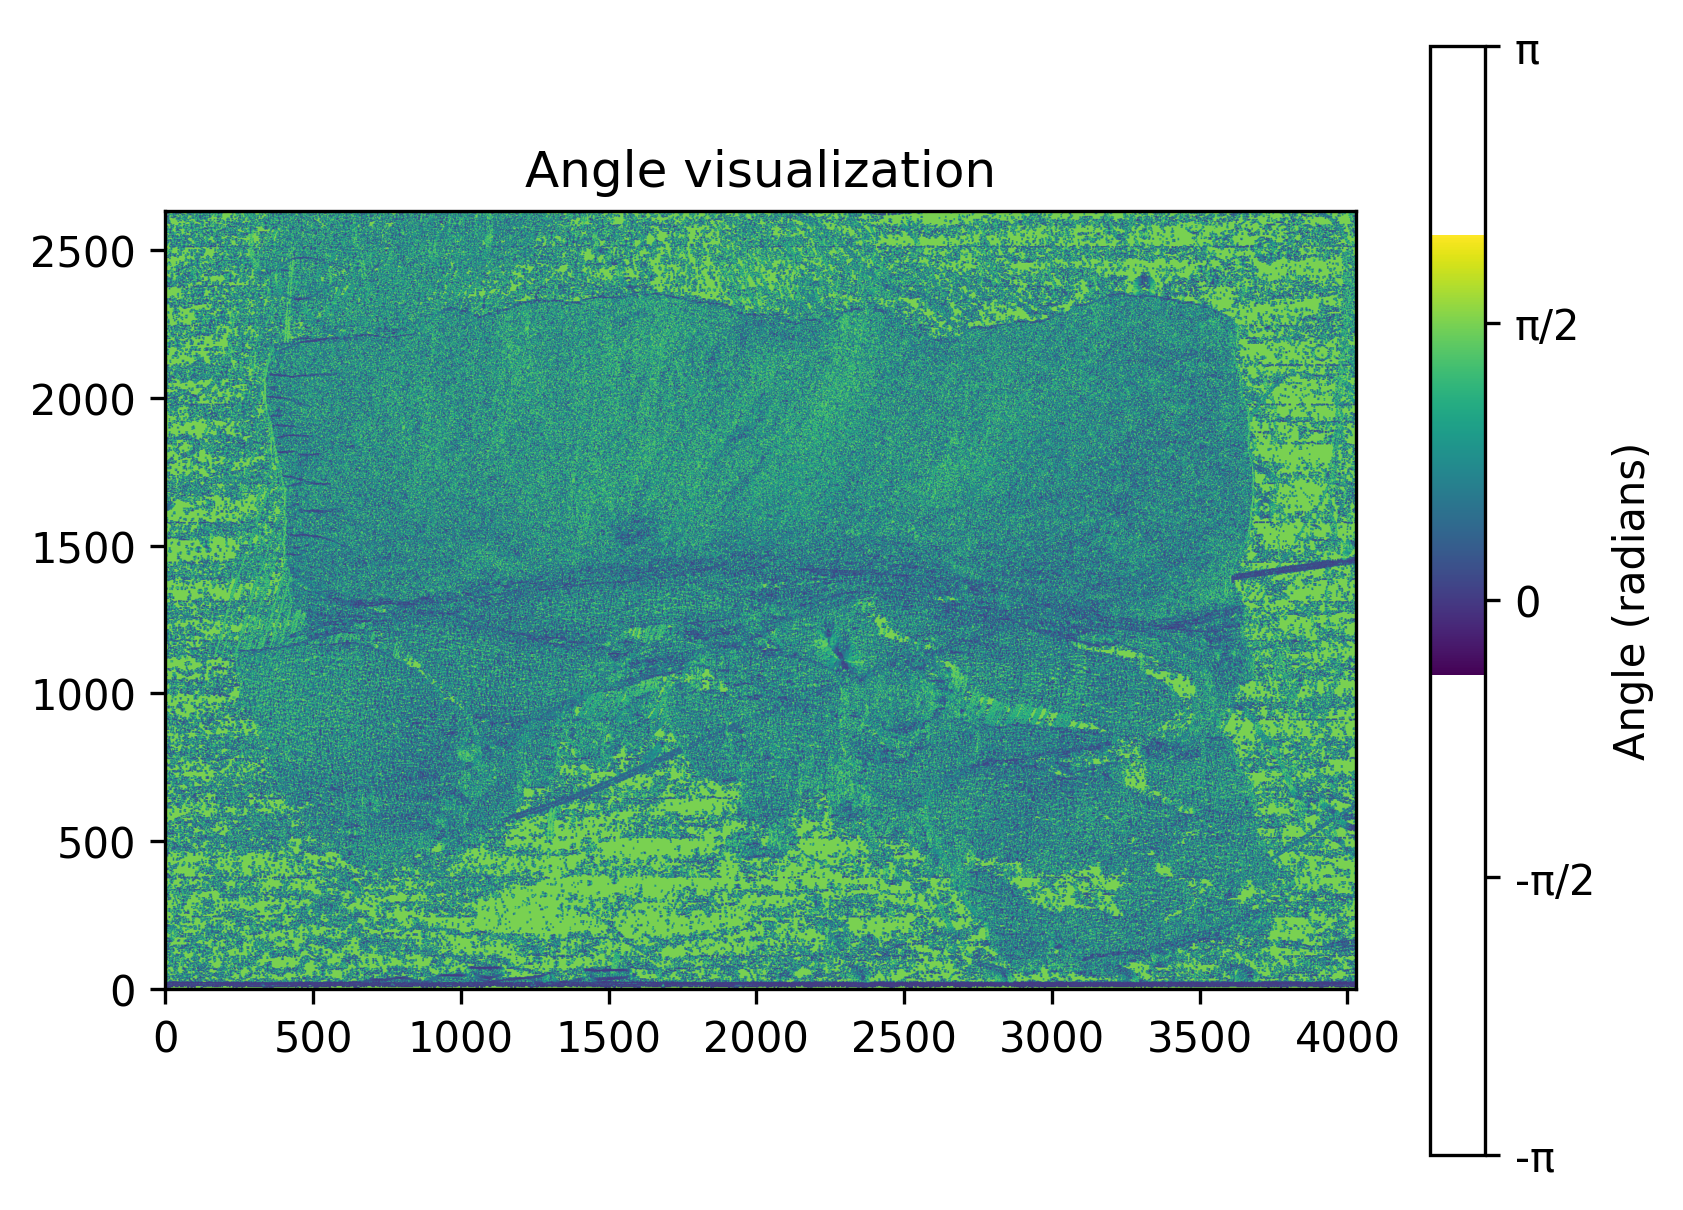

In [7]:
plt.figure()
im = plt.imshow(theta_reconstructed_np, cmap='viridis', origin='lower')

# Add colorbar with meaningful ticks
cbar = plt.colorbar(im)
cbar.set_label('Angle (radians)')
cbar.set_ticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
cbar.set_ticklabels(['-π', '-π/2', '0', 'π/2', 'π'])

plt.title("Angle visualization")
plt.show()

(array([   7008.,  396555., 1243949., 1585769., 1658138., 1643217.,
        1568878., 1822877.,  673381.,    5952.]),
 array([-0.42523673, -0.17572589,  0.07378495,  0.3232958 ,  0.5728066 ,
         0.82231748,  1.07182837,  1.32133913,  1.57085001,  1.8203609 ,
         2.06987166]),
 <BarContainer object of 10 artists>)

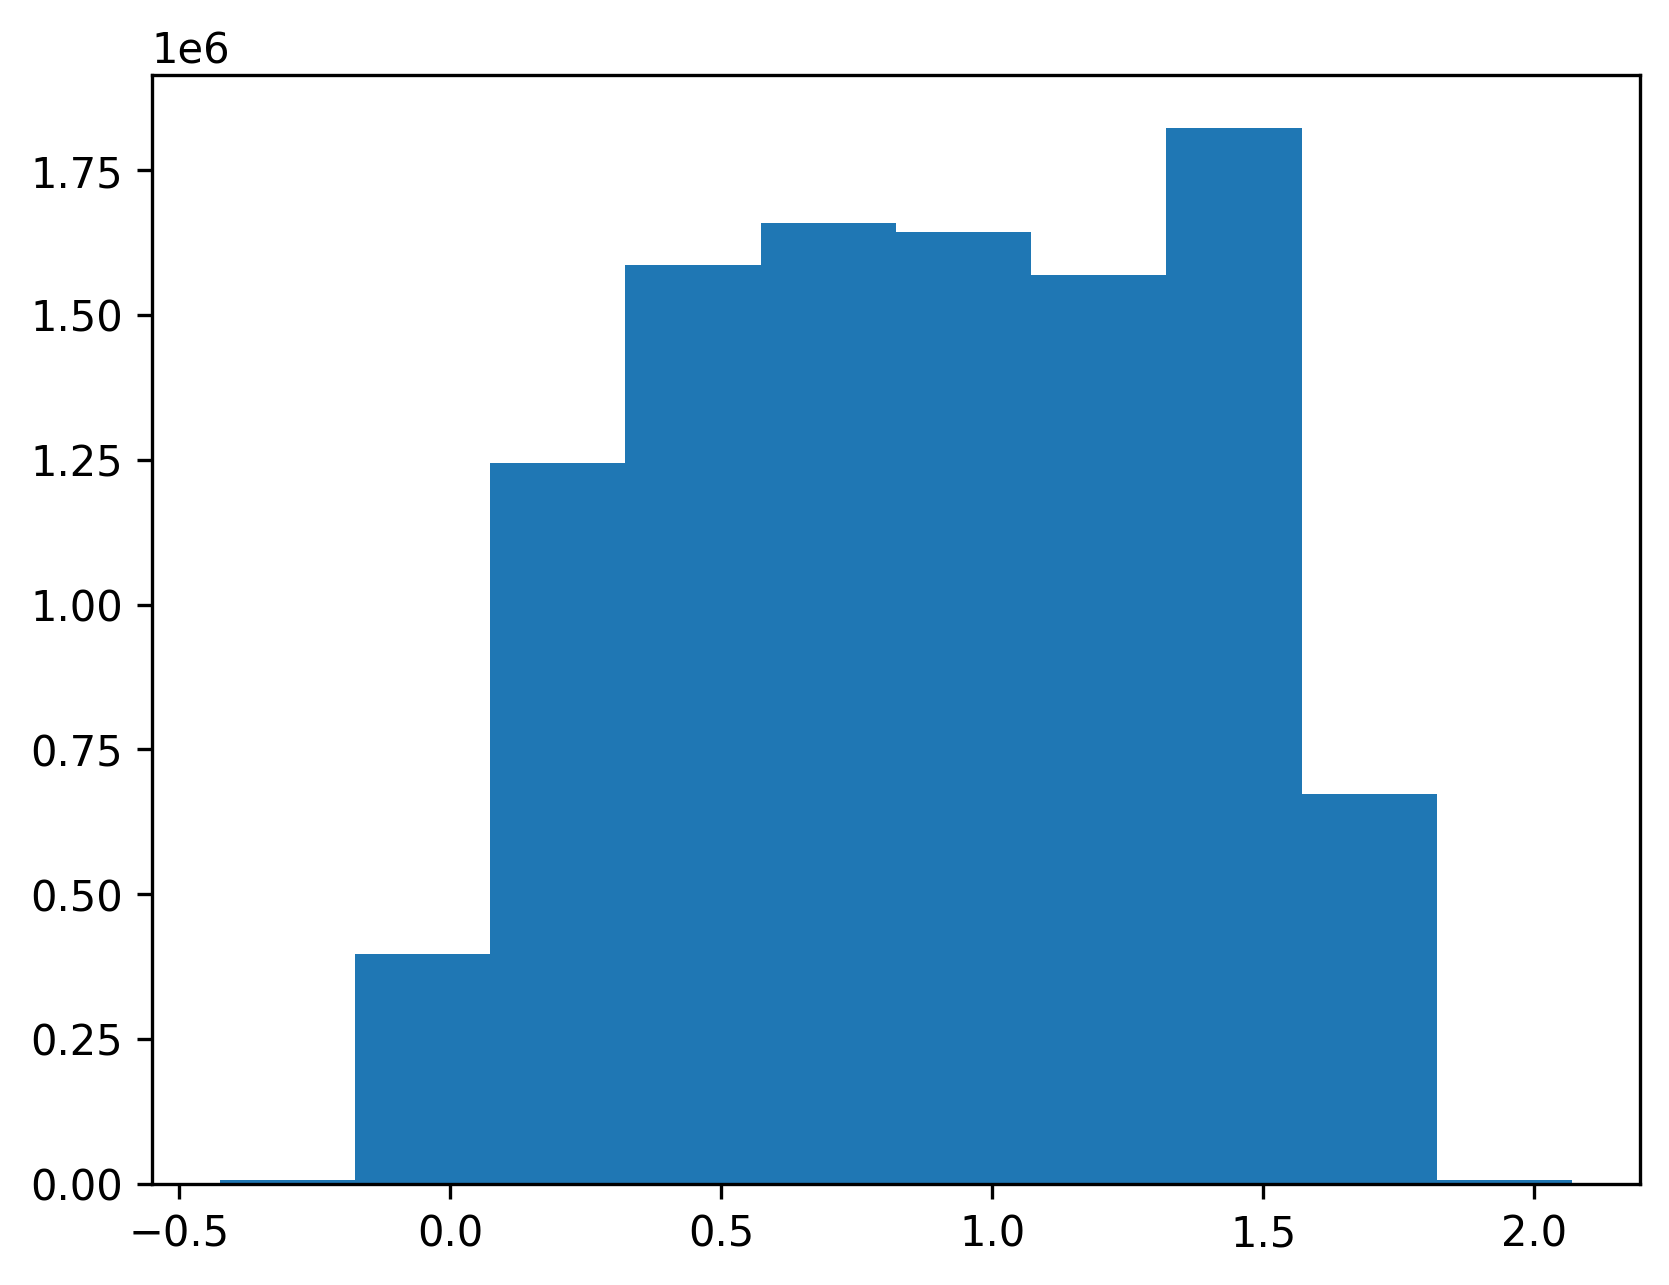

In [23]:
plt.hist(theta_reconstructed_np.flatten())